# Notebook for WIND L2 rad1 data - playing with the data using maser-data

## Import lib

In [ ]:
# Packages that will be used
import numpy as np
import xarray

# importing maser
base_dir = "/home/Projets/my_data/wind/"  # to adapt to your own directory data location
from maser.data import Data

## Setting and Read CDF file

In [ ]:
# data can be found and downloaded at: https://maser.obspm.fr/repository/wind/waves/wi_wa_rad1_l2_v01/data/2024/02/wi_wa_rad1_l2_20240204_v01.dat
filename = base_dir + "wi_wa_rad1_l2_20240204_v01.dat"
data_wind = Data(filename)

After this, the WIND data file is "opened". No data have been extracted yet, and to do so we will use the `as_xarray()` method:

In [3]:
xr_wi = data_wind.as_xarray()
print(xr_wi.keys())

KeysView(<xarray.Dataset>
Dimensions:    (frequency: 32, time: 14656)
Coordinates:
  * frequency  (frequency) float64 20.0 24.0 28.0 32.0 ... 804.0 916.0 1.04e+03
  * time       (time) datetime64[ns] 2024-02-04T00:00:04.126952 ... 2024-02-0...
Data variables:
    VS         (frequency, time) float64 nan nan nan ... 0.004541 0.003272
    VSP        (frequency, time) float64 nan nan nan ... 0.003453 0.002789
    VZ         (frequency, time) float64 nan nan nan ... 0.0003414 0.0003137
    TS         (frequency, time) float64 nan nan nan nan nan ... 0.0 0.0 0.0 0.0
    TSP        (frequency, time) float64 nan nan nan ... 0.1539 0.1539 0.1539
    TZ         (frequency, time) float64 nan nan nan ... 0.07698 0.07698 0.07698
    MODE       (frequency, time) float64 nan nan nan nan nan ... 3.0 3.0 3.0 3.0)


In [4]:
xr_wi

<xarray.Dataset>
Dimensions:    (frequency: 32, time: 14656)
Coordinates:
  * frequency  (frequency) float64 20.0 24.0 28.0 32.0 ... 804.0 916.0 1.04e+03
  * time       (time) datetime64[ns] 2024-02-04T00:00:04.126952 ... 2024-02-0...
Data variables:
    VS         (frequency, time) float64 nan nan nan ... 0.004541 0.003272
    VSP        (frequency, time) float64 nan nan nan ... 0.003453 0.002789
    VZ         (frequency, time) float64 nan nan nan ... 0.0003414 0.0003137
    TS         (frequency, time) float64 nan nan nan nan nan ... 0.0 0.0 0.0 0.0
    TSP        (frequency, time) float64 nan nan nan ... 0.1539 0.1539 0.1539
    TZ         (frequency, time) float64 nan nan nan ... 0.07698 0.07698 0.07698
    MODE       (frequency, time) float64 nan nan nan nan nan ... 3.0 3.0 3.0 3.0

In [5]:
xr_wi["VS"].attrs

{'units': 'uV2/Hz'}

We will first display a quicklook of the data:

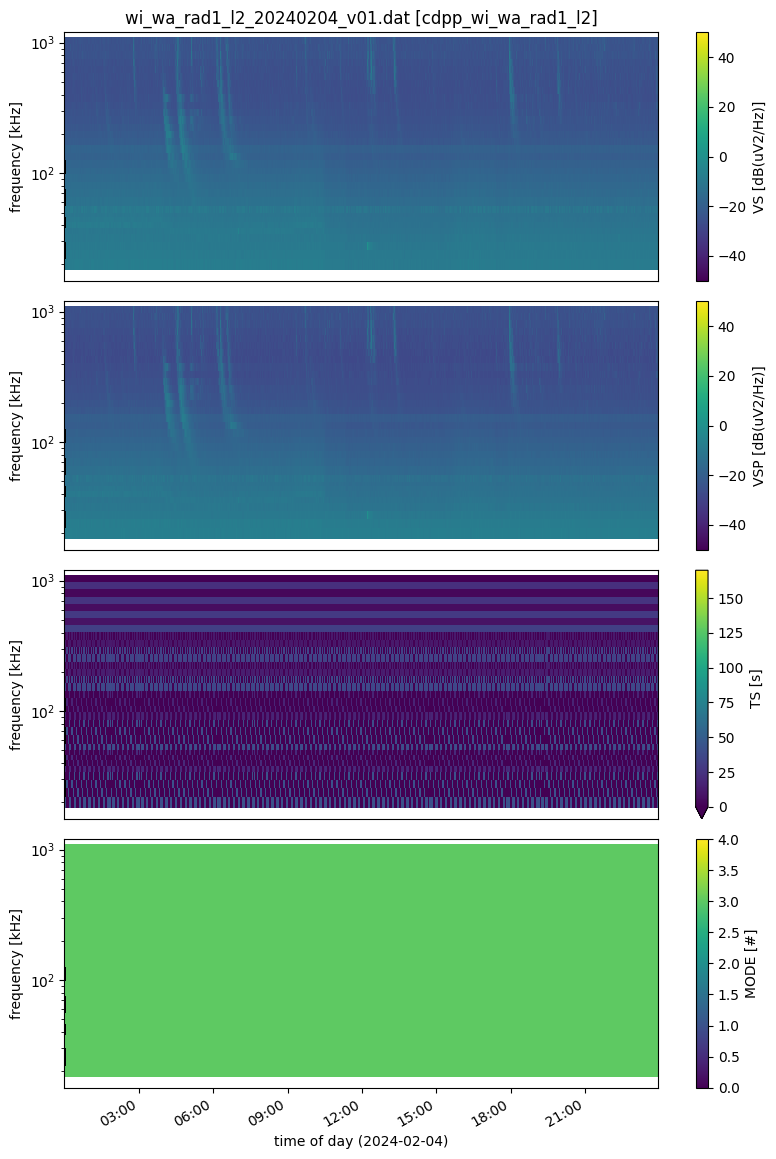

In [6]:
data_wind.quicklook(keys=["VS", "VSP", "TS", "MODE"], cmap="viridis")

We will now only focus on one of the data array (here `VS`, but same could be applied to the others).

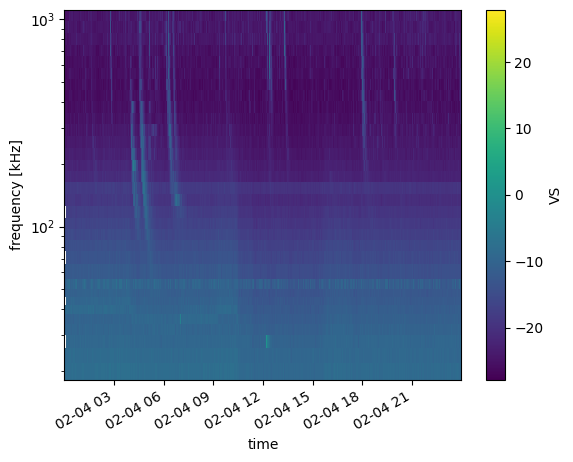

In [7]:
# re-extracting the data using the base options
xr_wi = data_wind.as_xarray()

# Display of the extracted array directly
(10*np.log10(xr_wi["VS"])).plot(cmap="viridis", yscale="log")

On this example, we "reconstructed" the WIND l2 data as an array-like object, but the data behind was recorded on a specific format not natively compatible with a 2D representation. In order to display the data as a 2D array, there are a few methods, and we implemented 2 within maser-data. Base option (above), fills empty data bins using the last known measurement at the same frequency (and thus we use the least older Epoch measurement). This is the default option, and thus the one used in `quicklook()` as well. Problem with this method is that bins are not centered on their time measurements, but the time of measurement will always correspond to the first Epoch of a given constant bin.

We also let the users decide if they want to get the data without any data gap filling; to do so, key arg `replicate=False` should be use within `as_xarray()`:

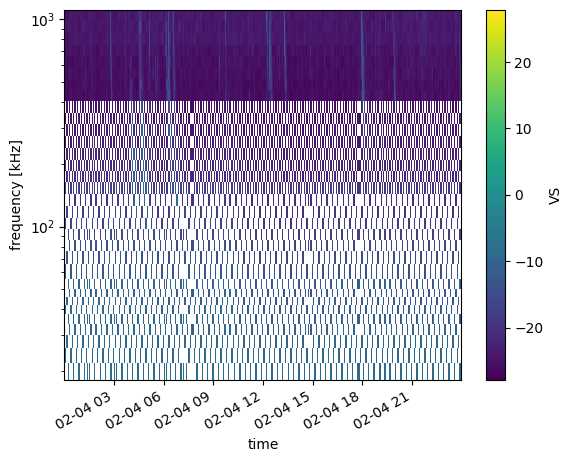

In [8]:
xr_wi_nan = data_wind.as_xarray(replicate=False)
(10*np.log10(xr_wi_nan["VS"])).plot(cmap="viridis", yscale="log")

In this case, all data bins have correct sizes and bins without records are just left empty. This is better for analysis, however, it is visually more complicated to get a fair representation of the data. Note that by zooming in, it is possible to recognize the features:

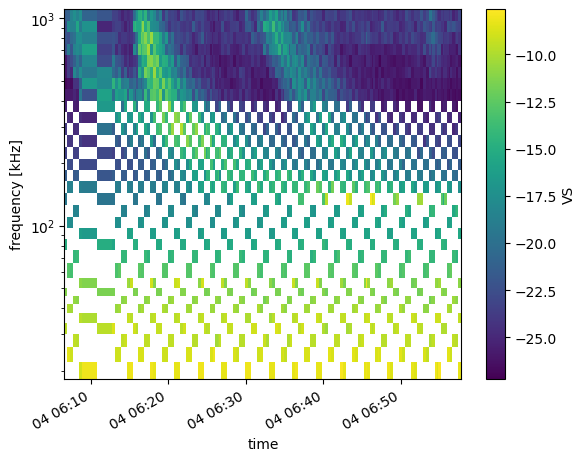

In [9]:
(10*np.log10(xr_wi_nan["VS"][:,3750:4250])).plot(cmap="viridis", yscale="log")

And the data looks very similar to the reconstructed array with gaps filled:

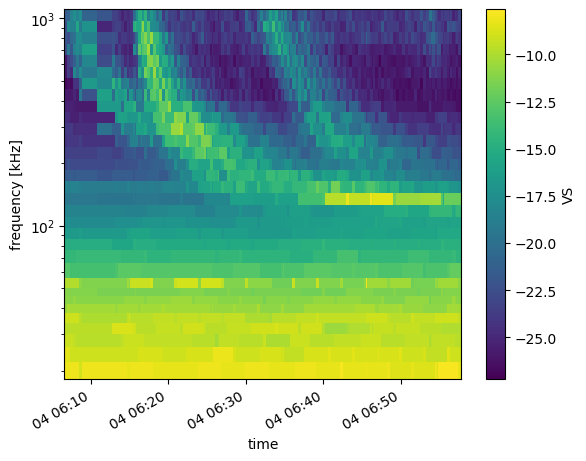

In [10]:
(10*np.log10(xr_wi["VS"][:,3750:4250])).plot(cmap="viridis", yscale="log")

We can discuss a few features here:
- on the last pannel, we can see that lower frequency bins are indeed larger than the higher frequency ones, which is expected given that the time sampling has a higher rate at high frequency (also visible on the array with nans);
- all the bins does not have strictly the same sizes in time. Two bins around 06:10 display particularly larger time extend. This is because xarray uses the x and y axis values to localise each bin, but if a record is missing it will still connect the previous data bin to the one immediatly after (hence, we choose by default the same behaviour in reconstructing the array, whith `replicate=True`);
- WIND data are not always taken regularly and even at low frequency some records immediatly follow each others, while others do not (visible as change of colours on very small bins on the first pannel ; and visible as very long bins in time, followed by very short ones on the second pannel);
- both pannels can be zoomed in using the same values (the bins are the same, but on the first case the previous value is copied, while with the later it is left empty as a nan);
- features are identifiable the same way on both pannel, with slightly different render.

# Advanced data extraction: detail of maser routine

Below is the advanced detail on how these computations are made within maser-data.

It is documented a bit with some explanations, but the computation is relatively long end dense and might be only interesting for advanced users that really want to dig into the data extraction in detail.

Please note that we are using a feature of maser-data that was not described before in this notebook: maser-data has the capability to represent/extract the data sweep by sweep. This feature is required for binnary datasets and we thus use it here (this feature is also available for cdf files, but is not used within their `as_xarray` methods since they are not required there to extract the data).

In [11]:
# Parameter to be changed depend on which mode you want to use:
replicate=True

# Retrieving datasets info:
fields = data_wind.fields
units = data_wind.units
fields.append("MODE")
units.append("#")

# preparing the data reorganisation
data_reorg = {}
for dataset_key in fields:
    data_reorg[dataset_key] = np.full(
        (np.shape(data_wind.frequencies[0])[0], len(data_wind.times)), np.nan
    )  # final 2D array
sweep_loc = 0
freq_ref = data_wind.frequencies[0].value[...]

# Here is the main loop, on each sweep:
for s in data_wind.sweeps:
    header = s.header
    nzpalf = header["NZPALF"]
    nspalf = header["NSPALF"]
    if nspalf != nzpalf * 2:
        print(
            "WARNING: Wind data has unexpected dimensions, process might fail."
        )
    sweep_degen_level = 0
    sweep_freqs = s.data["FREQ"][:, 0]  # Freqs in the current sweep
    sweep_freq_list = np.sort(list(set(sweep_freqs)))  # unique freqs
    freq_degen = []
    freq_loc = {}
    for i in range(len(sweep_freq_list)):
        freq_degen = np.append(
            freq_degen,
            int(np.count_nonzero(sweep_freqs == sweep_freq_list[i])),
        )  # number of time this freq is used per sweep
        freq_loc[sweep_freq_list[i]] = np.where(
            sweep_freqs == sweep_freq_list[i]
        )  # location of ach freq in the unique freq table
    sweep_degen_level = int(
        np.max(freq_degen)
    )  # max number of time a freq is measured within a sweep
    sub_sweep_len = int(
        header["NPALIF"] // sweep_degen_level
    )  # time between measuring the same freq
    sweep_degen_frac = np.array(sweep_degen_level // freq_degen, dtype=int)

    dts = s.data["TS"]
    dtsp = s.data["TSP"]
    dtz = s.data["TZ"]
    dtmin = np.min(
        [dts.T.flatten(), dtsp.T.flatten(), dtz.T.flatten()], axis=0
    )
    t_out_min = sweep_loc
    t_out_max = sweep_loc + sweep_degen_level * nzpalf
    delta_times = []

    # recording the time delay between each Epoch and the moment the corresponding value was taken
    for i in range(sweep_degen_level):
        loc = i * sub_sweep_len * nzpalf
        delta_times = np.append(
            delta_times,
            dtmin[loc : loc + nzpalf],
        )
    for i in range(len(sweep_freq_list)):  # for each unique freq
        freq_out = int(np.where(sweep_freq_list[i] == freq_ref)[0][0])
        freq = sweep_freq_list[i]
        freq_in = []
        time_out_final = np.arange(t_out_min, t_out_max, 1)
        if False:
            # Technically works, probably faster
            # but copy each subsweep as is and thus not the last measurement (full nzpalf vector is used)
            freq_in = (
                np.tile(
                    freq_loc[freq], (sweep_degen_frac[i], 1)
                ).T.flatten(),
            )
            time_out = time_out_final
        else:
            # Computing the output Epoch vector for the current sweep
            freq_in = freq_loc[freq]
            nztab = np.tile(
                np.arange(0, nzpalf, 1), (len(freq_loc[freq][0]), 1)
            )
            time_out = np.tile(
                np.array(freq_loc[freq]) // sub_sweep_len * nzpalf,
                (nzpalf, 1),
            ).T
            time_out = (time_out + nztab + t_out_min).flatten()
        if replicate:
            # replace all NaN by the last previous value
            nan_mask = np.in1d(time_out_final, time_out)
            nan_loc = time_out_final[np.where(~nan_mask)[0]]
            replace_loc = np.copy(nan_loc)
            for k in range(len(replace_loc)):
                replace_loc[k] = (
                    time_out.searchsorted(replace_loc[k], "right") - 1
                )
            if sweep_loc == 0:
                replace_loc = replace_loc[np.where(replace_loc > 0)]
                nan_loc = nan_loc[np.where(replace_loc > 0)]
            replace_loc = np.append(time_out, [np.min(time_out_final) - 1])[
                replace_loc
            ]
        # else will let the nan in place
        for dataset_key in fields:
            # preparing data for output
            if dataset_key == "MODE":
                d = np.full(np.shape(dts), np.nan)
                d[:] = int(header["MODE"])
            elif dataset_key == "FREQ_DEGEN":
                d = np.full(np.shape(dts), np.nan)
                d[:] = int(sweep_degen_frac[i])
            elif dataset_key == "FREQ":
                d = np.full(np.shape(dts), np.nan)
                d[:] = freq
            else:
                d = s.data[dataset_key]
            # writing the output data at the good location:
            data_reorg[dataset_key][freq_out, time_out] = d[
                :, freq_in
            ].T.flatten()
            if replicate:
                # replace all NaN by the last previous value
                data_reorg[dataset_key][freq_out, nan_loc] = data_reorg[
                    dataset_key
                ][freq_out, replace_loc]
            # else dont
            if dataset_key in ["TS", "TSP", "TZ"]:
                # modifying these variable to take into account modification we made to Epoch
                data_reorg[dataset_key][
                    freq_out, time_out_final
                ] -= delta_times
    sweep_loc += sweep_degen_level * nzpalf

# preparing outputs:
datasets = {}
for dataset_key, dataset_unit in zip(fields, units):
    data_arr = data_reorg[dataset_key]

    datasets[dataset_key] = xarray.DataArray(
        data=data_arr,
        name=dataset_key,
        coords=[
            ("frequency", data_wind.frequencies[0].value, {"units": "kHz"}),
            ("time", data_wind.times.to_datetime(), {}),
        ],
        attrs={"units": dataset_unit},
        dims=("frequency", "time"),
    )
# and this is the final product extracted:
xarr_out = xarray.Dataset(data_vars=datasets)

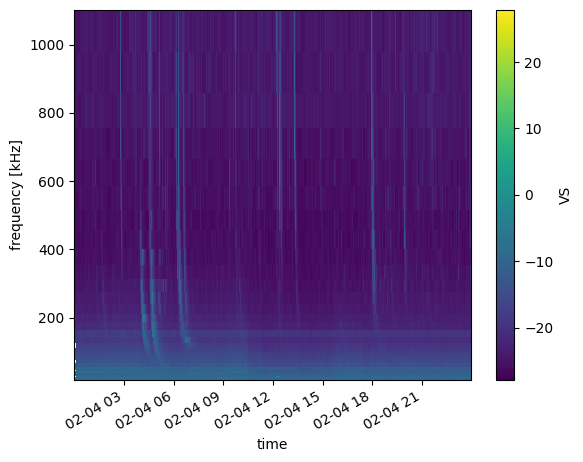

In [12]:
# Let's display it:
(10.*np.log10(xarr_out["VS"])).plot(cmap="viridis")